# Querying the liver cell atlas

In [46]:
import requests
import pandas as pd
from io import StringIO
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap, Normalize
import matplotlib.cm as cm
import matplotlib.image as mpimg
import numpy as np
import PIL.Image  # For opening images
import urllib.request  # For downloading images from a URL

# Building the UMAP plots

In [18]:
# first fetch the list of genes in their db (only do this once cuz this data won't change)
url = "https://www.livercellatlas.org/data_files/allGenes_humanAll.txt"
response = requests.get(url)

# Check if the request was successful
if response.status_code == 200:
    # Process the response content
    gene_list = response.text.strip().split()
    # Perform further processing with 'data'
else:
    print(f"Request failed with status code {response.status_code}")

In [21]:
# then fetch the tSNE positions of all the liver cell types (only do this once cuz this data won't change)
url = "https://www.livercellatlas.org/data_files/tsneTable_humanAll.csv"
response = requests.get(url)

# Check if the request was successful
if response.status_code == 200:
    # Process the response content
    tSNE_data = pd.read_csv(StringIO(response.text))
    # Perform further processing with 'data'
else:
    print(f"Request failed with status code {response.status_code}")

In [49]:
# load the png for the UMAP with cell type labels
image_url = "https://www.livercellatlas.org/img/umap_humanAll.png"
uMAP_labels_img = np.array(PIL.Image.open(urllib.request.urlopen(image_url)))
print(uMAP_labels_img.shape)

(2100, 2100, 4)


In [15]:
# now find the position of the gene of interest
position = None
gene = "PNPLA3"
for i,g in enumerate(gene_list):
    if g == gene:
        position = i+2
        break
else:
    raise ValueError(f"gene {gene} not found in gene_list")
print(f"use line# {position}")

use line# 28368


In [25]:
# Define the URL
url = f'https://www.livercellatlas.org/getGeneData_fast.php?geneLine={position}&sample=logTable_humanAll'

# Perform the GET request
response = requests.get(url)

# Check if the request was successful
if response.status_code == 200:
    # Process the response content
    expression_data = pd.read_csv(StringIO(response.text))
else:
    print(f"Request failed with status code {response.status_code}")

# now to join the expression data with the tSNE data
sample_2_expr = {c:float(expression_data[c].values[0]) for c in expression_data.columns}
tSNE_data_w_expr = pd.DataFrame(tSNE_data)
tSNE_data_w_expr[f"{gene}_expr"] = [sample_2_expr[s] for s in tSNE_data_w_expr.Sample]

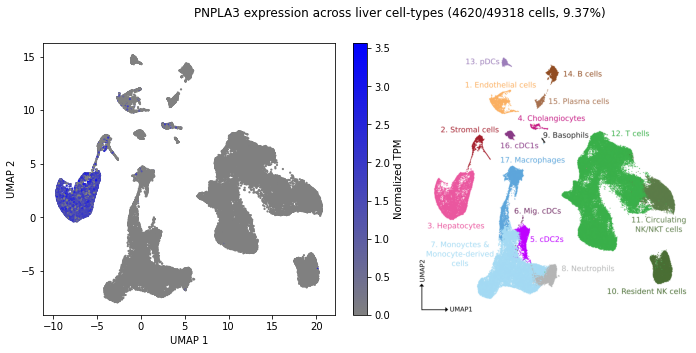

In [80]:
fig, axes = plt.subplots(1, 2, figsize=((6+5)*1.2, 5), gridspec_kw={'width_ratios': [1.2,1]})
custom_cmap = LinearSegmentedColormap.from_list("gray_to_blue", ["gray", "blue"])
sns.scatterplot(data=tSNE_data_w_expr,
                x="tSNE_1",
                y="tSNE_2",
                hue=f"{gene}_expr",
                palette=custom_cmap,
                legend=None,
                ax=axes[0],
                edgecolor='none',
                s=5
               )
cbar = plt.colorbar(cm.ScalarMappable(cmap=custom_cmap, 
                                      norm=Normalize(vmin=min(tSNE_data_w_expr[f"{gene}_expr"]),
                                                     vmax=max(tSNE_data_w_expr[f"{gene}_expr"]))),
                    ax=axes[0])
cbar.set_label("Normalized TPM")
axes[0].set_ylabel("UMAP 2")
axes[0].set_xlabel("UMAP 1")
tot_cells = len(tSNE_data_w_expr)
expr_cells = sum(tSNE_data_w_expr[f'{gene}_expr'] != 0)
expr_cells_p = round(expr_cells/tot_cells*100,2)
axes[1].imshow(uMAP_labels_img)
axes[1].axis('off')

# Manually adjust the second plot's position
pos1 = axes[0].get_position()  # Get original position of the first plot
pos2 = [pos1.x1 + 0.03, pos1.y0, 0.4, pos1.height]  # Shift right, increase width
axes[1].set_position(pos2)

fig.suptitle(f"{gene} expression across liver cell-types ({expr_cells}/{tot_cells} cells, {expr_cells_p}%)")
plt.show()

# Get Expression Counts against cell types

In [75]:
gene = "PNPLA3"
# Define the URL
url = f'https://www.livercellatlas.org/getVlnData.php?geneSymbol={gene}&sample=vlnTable_humanAll'

# Perform the GET request
response = requests.get(url)

# Check if the request was successful
if response.status_code == 200:
    # Process the response content
    data = pd.read_csv(StringIO(response.text))
    # Perform further processing with 'data'
else:
    print(f"Request failed with status code {response.status_code}")

In [76]:
data

,cluster,diet,annotDiet,PNPLA3
0,Endothelial cells,Lean,Endothelial cells-Lean,0.000000
1,Endothelial cells,Lean,Endothelial cells-Lean,1.542544
2,Endothelial cells,Lean,Endothelial cells-Lean,0.000000
3,Endothelial cells,Lean,Endothelial cells-Lean,0.000000
4,Endothelial cells,Lean,Endothelial cells-Lean,0.000000
...,...,...,...,...
7962,Macrophages,Obese,Macrophages-Obese,0.000000
7963,Macrophages,Obese,Macrophages-Obese,0.000000
7964,Macrophages,Obese,Macrophages-Obese,0.000000
7965,Macrophages,Obese,Macrophages-Obese,0.000000
